In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED  = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEPHORA_COLOR = "#E91E63"
ULTA_COLOR    = "#9C27B0"
BOTH_COLOR    = "#FF9800"
NEUTRAL       = "#90A4AE"

In [2]:
sephora_df = pd.read_csv(PROCESSED / "Sephora" / "sephora_segmentation.csv",
                          dtype={"product_id": str})
ulta_df    = pd.read_csv(PROCESSED / "Ulta"    / "ulta_segmentation.csv",
                          dtype={"product_id": str})
matched    = pd.read_csv(PROCESSED / "Matched" / "matched_pairs.csv",
                          dtype={"sephora_product_id": str,
                                 "ulta_product_id":    str})

# Five positioning dimensions — use whichever cols exist
DIMS = {
    "efficacy": [
        "avg_rating", "pct_5_star", "pct_positive",
    ],
    "experience_quality": [
        "avg_sentiment", "pct_negative",          # pct_negative inverted below
    ],
    "polarization": [
        "rating_std", "pct_1_star", "rating_dispersion_over_time",
    ],
    "market_traction": [
        "reviews_per_month", "review_count_normalized",
    ],
    "value_efficiency": [
        "price_vs_category_median",               # relative price premium
        "avg_rating",                             # re-weighted against price in score
    ],
}

def brand_profile(df, platform):
    """Aggregate product-level features to brand means."""
    brand_col = "brand_normalized" if "brand_normalized" in df.columns else "brand"
    all_feat   = [c for c in df.columns
                  if df[c].dtype in [np.float64, np.float32, np.int64]
                  and c not in ("product_id",)]
    agg = (
        df.groupby(brand_col)
        .agg(
            n_products = (brand_col, "count"),
            **{f: (f, "mean") for f in all_feat if f in df.columns}
        )
        .reset_index()
        .rename(columns={brand_col: "brand"})
    )
    agg["platform"] = platform

    # Derived value-efficiency score: avg_rating / price (if price available)
    if "avg_rating" in agg.columns and "price" in agg.columns:
        agg["rating_per_dollar"] = (
            agg["avg_rating"] / agg["price"].replace(0, np.nan)
        )
    # Invert pct_negative so higher = better on all dims
    if "pct_negative" in agg.columns:
        agg["pct_positive_sentiment"] = 1 - agg["pct_negative"]

    return agg

s_brand = brand_profile(sephora_df, "Sephora")
u_brand = brand_profile(ulta_df,    "Ulta")

# Brands present on both platforms
both_brands = set(s_brand["brand"]) & set(u_brand["brand"])
print(f"Sephora brands : {len(s_brand):,}")
print(f"Ulta brands    : {len(u_brand):,}")
print(f"Shared brands  : {len(both_brands):,}")

Sephora brands : 309
Ulta brands    : 588
Shared brands  : 100


In [3]:
# Five composite scores per brand, computed from available columns

def composite_scores(df):
    scores = pd.DataFrame({"brand": df["brand"], "platform": df["platform"],
                            "n_products": df["n_products"]})

    # 1. Efficacy — how well products are rated
    eff_cols = [c for c in ["avg_rating", "pct_5_star", "pct_positive"] if c in df.columns]
    if eff_cols:
        scores["efficacy"] = df[eff_cols].mean(axis=1)

    # 2. Experience quality — sentiment signal strength
    exp_cols = [c for c in ["avg_sentiment", "pct_positive_sentiment"] if c in df.columns]
    if not exp_cols and "pct_negative" in df.columns:
        exp_cols_raw = ["pct_negative"]
        scores["experience_quality"] = 1 - df["pct_negative"]
    elif exp_cols:
        scores["experience_quality"] = df[exp_cols].mean(axis=1)

    # 3. Polarization — how divisive are the products
    pol_cols = [c for c in ["rating_std", "pct_1_star",
                             "rating_dispersion_over_time"] if c in df.columns]
    if pol_cols:
        scores["polarization"] = df[pol_cols].mean(axis=1)

    # 4. Market traction — review volume & velocity
    tra_cols = [c for c in ["reviews_per_month", "review_count_normalized"] if c in df.columns]
    if tra_cols:
        scores["market_traction"] = df[tra_cols].mean(axis=1)

    # 5. Value efficiency — rating relative to price tier
    if "rating_per_dollar" in df.columns:
        scores["value_efficiency"] = df["rating_per_dollar"]
    elif "price_vs_category_median" in df.columns and "avg_rating" in df.columns:
        # High rating, low relative price = high value efficiency
        scores["value_efficiency"] = df["avg_rating"] / (df["price_vs_category_median"] + 1e-6)

    # Price tier (raw, for annotation)
    if "price" in df.columns:
        scores["avg_price"] = df["price"]

    return scores

s_scores = composite_scores(s_brand)
u_scores = composite_scores(u_brand)
all_scores = pd.concat([s_scores, u_scores], ignore_index=True)

SCORE_COLS = [c for c in ["efficacy", "experience_quality", "polarization",
                           "market_traction", "value_efficiency"]
              if c in all_scores.columns]
print(f"\nPositioning dimensions available: {SCORE_COLS}")
print(f"Total brand-platform rows: {len(all_scores):,}")


Positioning dimensions available: ['efficacy', 'experience_quality', 'polarization', 'market_traction', 'value_efficiency']
Total brand-platform rows: 897


In [4]:
# Fit on brands with ≥ 2 products, drop rows with any NaN in score cols

pca_df = (all_scores[all_scores["n_products"] >= 2]
          .dropna(subset=SCORE_COLS)
          .reset_index(drop=True))

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(pca_df[SCORE_COLS])

pca = PCA(n_components=min(len(SCORE_COLS), 4), random_state=42)
components = pca.fit_transform(X_scaled)

pca_df["PC1"] = components[:, 0]
pca_df["PC2"] = components[:, 1]

explained = pca.explained_variance_ratio_
print(f"\nPCA explained variance:")
for i, ev in enumerate(explained):
    print(f"  PC{i+1}: {ev:.1%}  (cumulative: {explained[:i+1].sum():.1%})")

# Loadings table
loadings = pd.DataFrame(
    pca.components_.T,
    index=SCORE_COLS,
    columns=[f"PC{i+1}" for i in range(len(explained))]
)
print("\nComponent loadings:")
print(loadings.round(3).to_string())


PCA explained variance:
  PC1: 49.9%  (cumulative: 49.9%)
  PC2: 24.4%  (cumulative: 74.2%)
  PC3: 16.3%  (cumulative: 90.6%)
  PC4: 5.9%  (cumulative: 96.5%)

Component loadings:
                      PC1    PC2    PC3    PC4
efficacy           -0.505 -0.435 -0.191 -0.336
experience_quality -0.552 -0.201 -0.026  0.792
polarization        0.571 -0.061 -0.230  0.501
market_traction    -0.276  0.683  0.502  0.090
value_efficiency    0.196 -0.548  0.811  0.033


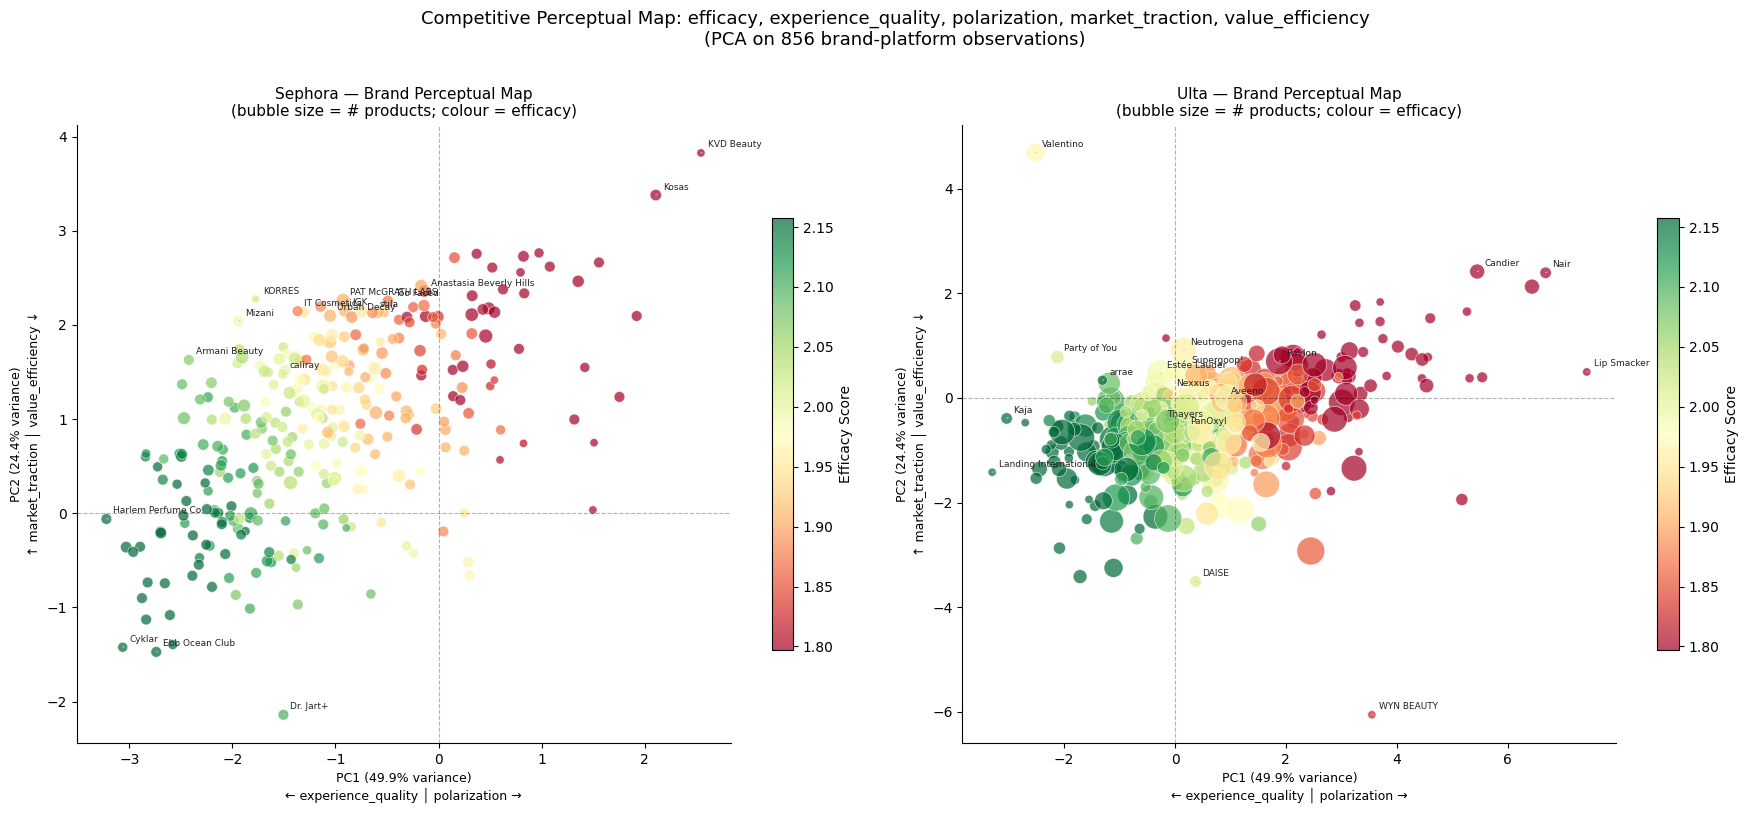

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, platform, color in [
    (axes[0], "Sephora", SEPHORA_COLOR),
    (axes[1], "Ulta",    ULTA_COLOR),
]:
    sub = pca_df[pca_df["platform"] == platform]
    scatter = ax.scatter(
        sub["PC1"], sub["PC2"],
        s=sub["n_products"] * 8 + 20,
        c=sub["efficacy"] if "efficacy" in sub.columns else color,
        cmap="RdYlGn", alpha=0.7, edgecolors="white", linewidths=0.5,
        vmin=pca_df["efficacy"].quantile(0.1) if "efficacy" in pca_df.columns else None,
        vmax=pca_df["efficacy"].quantile(0.9) if "efficacy" in pca_df.columns else None,
    )
    plt.colorbar(scatter, ax=ax, shrink=0.7, label="Efficacy Score")

    # Label top brands by traction + outlier position
    if "market_traction" in sub.columns:
        top_brands = sub.nlargest(12, "market_traction")
    else:
        top_brands = sub.head(12)

    # Also label positional extremes
    for extreme_col in ["PC1", "PC2"]:
        for fn in [sub.nlargest, sub.nsmallest]:
            for _, row in fn(2, extreme_col).iterrows():
                if row["brand"] not in top_brands["brand"].values:
                    top_brands = pd.concat([top_brands,
                                            pd.DataFrame([row])], ignore_index=True)

    for _, row in top_brands.drop_duplicates("brand").iterrows():
        ax.annotate(
            row["brand"],
            xy=(row["PC1"], row["PC2"]),
            xytext=(5, 4), textcoords="offset points",
            fontsize=6.5, color="#222",
            arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.6),
        )

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)\n"
                  f"← {loadings['PC1'].idxmin()} │ {loadings['PC1'].idxmax()} →",
                  fontsize=9)
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)\n"
                  f"↑ {loadings['PC2'].idxmax()} │ {loadings['PC2'].idxmin()} ↓",
                  fontsize=9)
    ax.set_title(f"{platform} — Brand Perceptual Map\n"
                 f"(bubble size = # products; colour = efficacy)",
                 fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Competitive Perceptual Map: {', '.join(SCORE_COLS)}\n"
    f"(PCA on {len(pca_df):,} brand-platform observations)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.1_perceptual_map.png", dpi=150, bbox_inches="tight")
plt.show()

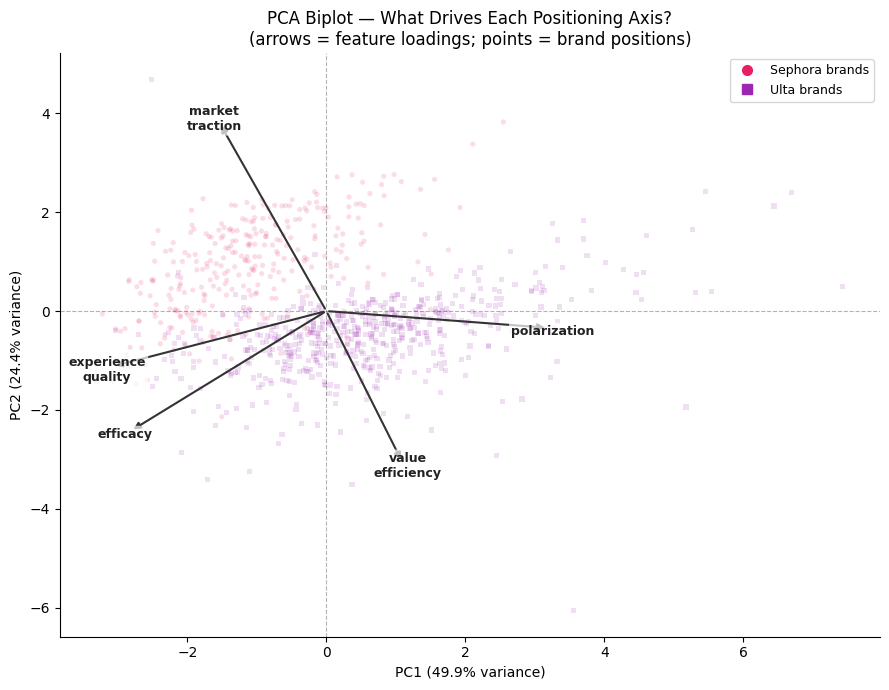

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

# Plot brand points (both platforms, lighter)
for platform, color, marker in [("Sephora", SEPHORA_COLOR, "o"),
                                  ("Ulta",    ULTA_COLOR,    "s")]:
    sub = pca_df[pca_df["platform"] == platform]
    ax.scatter(sub["PC1"], sub["PC2"], alpha=0.15, s=14,
               color=color, marker=marker, edgecolors="none")

# Loading vectors
scale = (pca_df[["PC1", "PC2"]].abs().max().max()) * 0.75
for dim in SCORE_COLS:
    lx = loadings.loc[dim, "PC1"] * scale
    ly = loadings.loc[dim, "PC2"] * scale
    ax.annotate("", xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.5))
    offset_x = 0.08 * (1 if lx >= 0 else -1)
    offset_y = 0.08 * (1 if ly >= 0 else -1)
    ax.text(lx + offset_x, ly + offset_y, dim.replace("_", "\n"),
            ha="center", va="center", fontsize=9, fontweight="bold",
            color="#222", bbox=dict(boxstyle="round,pad=0.2",
                                    facecolor="white", alpha=0.7, edgecolor="none"))

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.3)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)", fontsize=10)
ax.set_title("PCA Biplot — What Drives Each Positioning Axis?\n"
             "(arrows = feature loadings; points = brand positions)",
             fontsize=12)
legend_items = [
    mlines.Line2D([], [], marker="o", color=SEPHORA_COLOR, ls="", markersize=7,
                  label="Sephora brands"),
    mlines.Line2D([], [], marker="s", color=ULTA_COLOR,    ls="", markersize=7,
                  label="Ulta brands"),
]
ax.legend(handles=legend_items, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.1_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

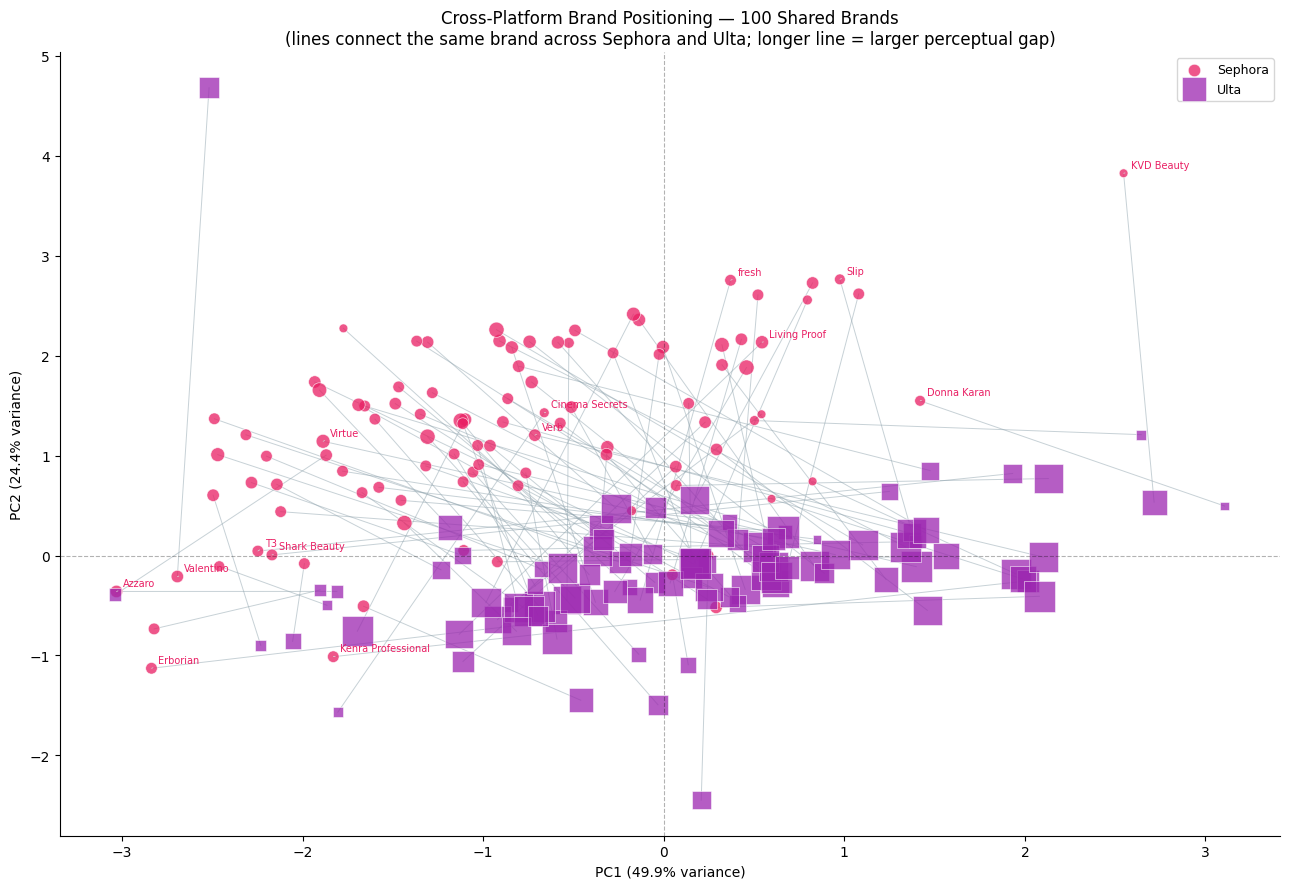

Brands with largest cross-platform perceptual displacement:
brand
Valentino             4.895
T3                    4.251
Kenra Professional    3.922
Shark Beauty          3.478
Living Proof          3.370
KVD Beauty            3.296
fresh                 3.240
Cinema Secrets        3.208
Verb                  3.069
Virtue                3.055
IGK                   3.050
KORRES                3.038
Murad                 3.000
MILK MAKEUP           2.983
PAT McGRATH LABS      2.958


In [7]:
shared_df = pca_df[pca_df["brand"].isin(both_brands)].copy()

if len(shared_df) > 0:
    fig, ax = plt.subplots(figsize=(13, 9))

    s_sub = shared_df[shared_df["platform"] == "Sephora"].set_index("brand")
    u_sub = shared_df[shared_df["platform"] == "Ulta"].set_index("brand")
    common = s_sub.index.intersection(u_sub.index)

    # Draw connecting lines first
    for brand in common:
        ax.plot([s_sub.loc[brand, "PC1"], u_sub.loc[brand, "PC1"]],
                [s_sub.loc[brand, "PC2"], u_sub.loc[brand, "PC2"]],
                color=NEUTRAL, lw=0.7, alpha=0.5, zorder=1)

    for sub, color, marker, platform in [
        (s_sub, SEPHORA_COLOR, "o", "Sephora"),
        (u_sub, ULTA_COLOR,    "s", "Ulta"),
    ]:
        ax.scatter(sub["PC1"], sub["PC2"],
                   s=sub["n_products"] * 10 + 20,
                   color=color, alpha=0.75, marker=marker,
                   edgecolors="white", linewidths=0.5,
                   label=platform, zorder=2)

    # Label brands with the largest cross-platform displacement
    if len(common) > 0:
        displacement = np.sqrt(
            (s_sub.loc[common, "PC1"] - u_sub.loc[common, "PC1"]) ** 2 +
            (s_sub.loc[common, "PC2"] - u_sub.loc[common, "PC2"]) ** 2
        ).sort_values(ascending=False)

        label_brands = set(displacement.head(10).index)
        # Also label brands at extreme positions
        for col in ["PC1", "PC2"]:
            for fn in [s_sub[col].nlargest, s_sub[col].nsmallest]:
                label_brands.update(fn(2).index.tolist())

        for brand in label_brands:
            if brand in s_sub.index:
                ax.annotate(brand, xy=(s_sub.loc[brand, "PC1"],
                                        s_sub.loc[brand, "PC2"]),
                            xytext=(5, 4), textcoords="offset points",
                            fontsize=7, color=SEPHORA_COLOR,
                            arrowprops=dict(arrowstyle="-", color="#ddd", lw=0.5))

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)", fontsize=10)
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)", fontsize=10)
    ax.set_title(
        f"Cross-Platform Brand Positioning — {len(common)} Shared Brands\n"
        "(lines connect the same brand across Sephora and Ulta; "
        "longer line = larger perceptual gap)",
        fontsize=12
    )
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.1_cross_platform_overlay.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # Cross-platform displacement ranking
    print("Brands with largest cross-platform perceptual displacement:")
    print(displacement.head(15).round(3).to_string())

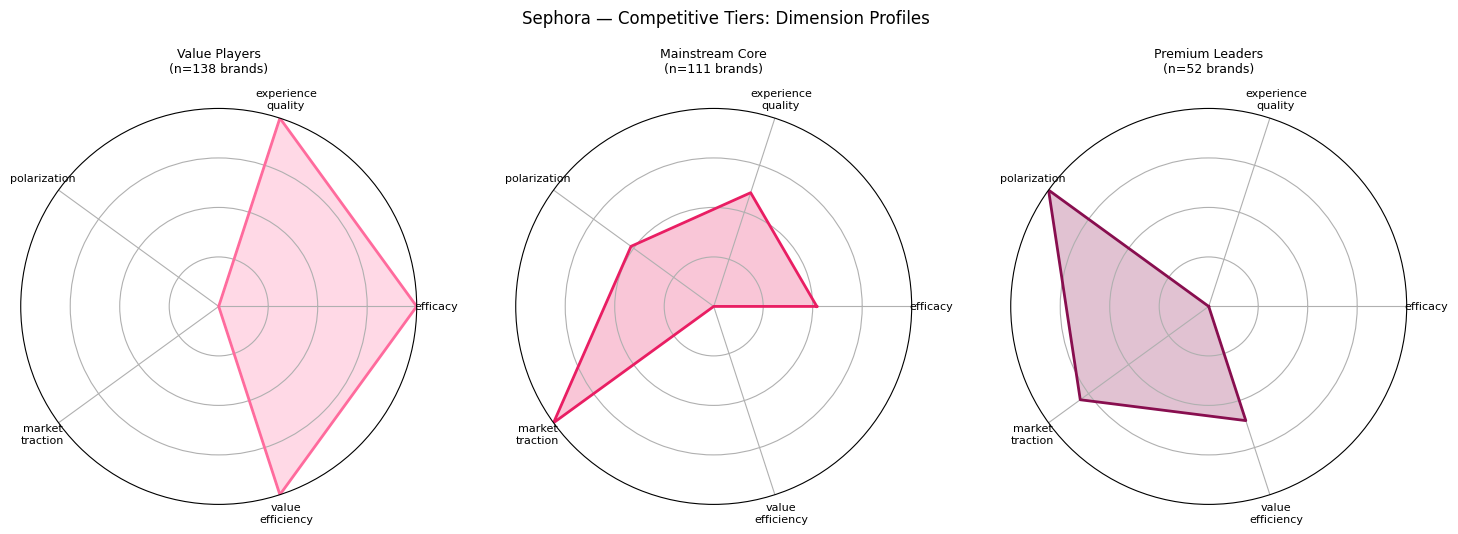

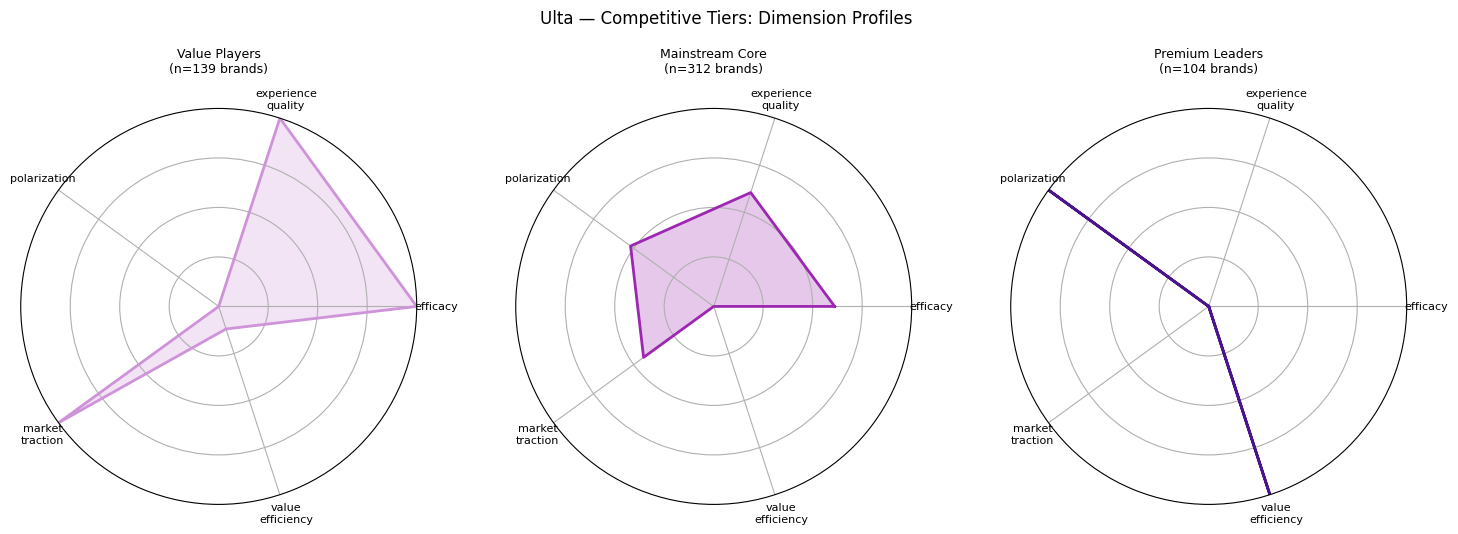

In [9]:
# Cluster brands into tiers on PC1/PC2, show average radar per tier

for platform, df_brand, shades in [
    ("Sephora", s_brand, ["#FF6B9D", "#E91E63", "#880E4F"]),
    ("Ulta",    u_brand, ["#CE93D8", "#9C27B0", "#4A148C"]),
]:
    sub = pca_df[pca_df["platform"] == platform].copy()
    if len(sub) < 4:
        continue

    # Hierarchical cluster into 3 tiers
    Z = linkage(sub[["PC1", "PC2"]].values, method="ward")
    sub["tier"] = fcluster(Z, t=3, criterion="maxclust")

    # Rank tiers by mean PC1: highest = Premium Leaders, lowest = Value Players
    tier_pc1_means = sub.groupby("tier")["PC1"].mean().rank()
    TIER_NAME_MAP  = {}
    for tier_id, rank in tier_pc1_means.items():
        if rank == tier_pc1_means.max():
            TIER_NAME_MAP[tier_id] = "Premium Leaders"
        elif rank == tier_pc1_means.min():
            TIER_NAME_MAP[tier_id] = "Value Players"
        else:
            TIER_NAME_MAP[tier_id] = "Mainstream Core"

    # Radar setup
    angles = np.linspace(0, 2 * np.pi, len(SCORE_COLS), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                              subplot_kw=dict(polar=True))

    tier_means      = sub.groupby("tier")[SCORE_COLS].mean()
    tier_means_norm = (tier_means - tier_means.min()) / (
        tier_means.max() - tier_means.min() + 1e-9
    )
    tier_sizes = sub.groupby("tier").size()

    # Sort tiers so left→right goes Value Players → Mainstream Core → Premium Leaders
    name_order  = ["Value Players", "Mainstream Core", "Premium Leaders"]
    sorted_tiers = sorted(tier_means_norm.index,
                          key=lambda t: name_order.index(TIER_NAME_MAP[t]))

    for ax, tier_id, shade in zip(axes, sorted_tiers, shades):
        row  = tier_means_norm.loc[tier_id]
        vals = row.tolist() + row.tolist()[:1]
        ax.plot(angles, vals, color=shade, lw=2)
        ax.fill(angles, vals, color=shade, alpha=0.25)
        ax.set_thetagrids(np.degrees(angles[:-1]),
                          [s.replace("_", "\n") for s in SCORE_COLS],
                          fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75])
        ax.set_yticklabels([])
        n = tier_sizes.get(tier_id, 0)
        ax.set_title(f"{TIER_NAME_MAP[tier_id]}\n(n={n} brands)",
                     fontsize=9, pad=12)

    fig.suptitle(f"{platform} — Competitive Tiers: Dimension Profiles",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"3.1_radar_{platform.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

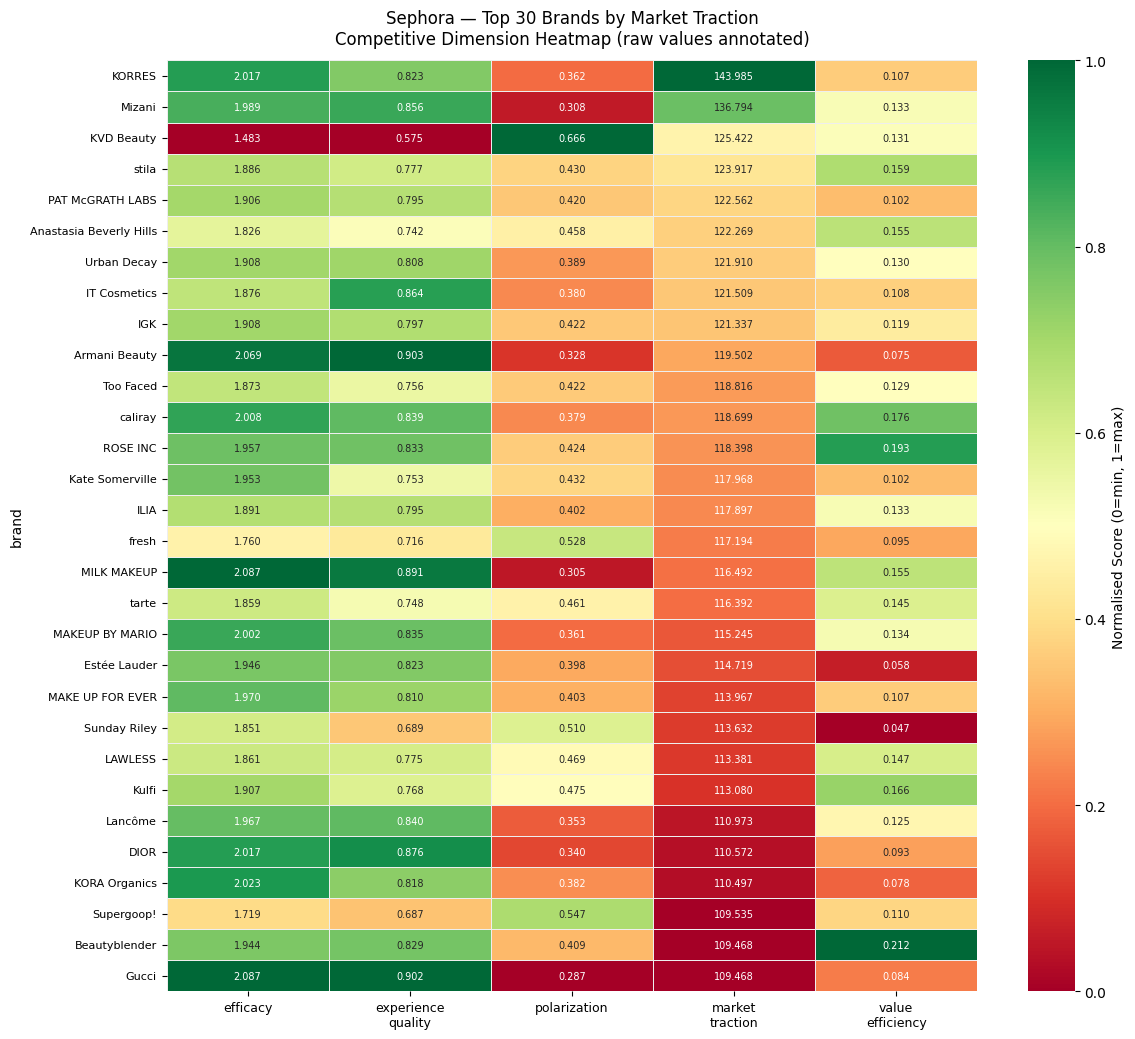

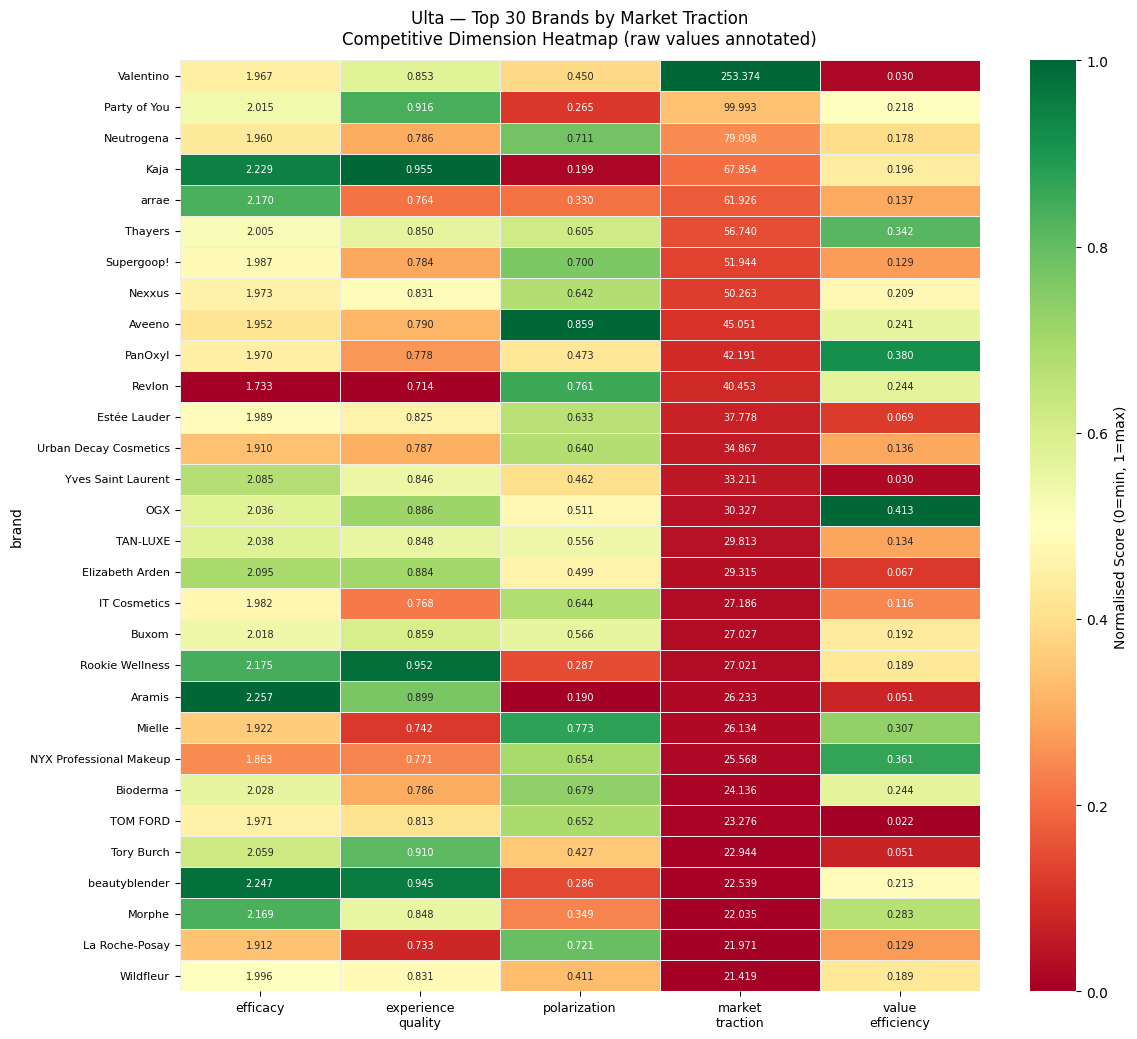

In [10]:
for platform, df_brand, color in [
    ("Sephora", s_brand, SEPHORA_COLOR),
    ("Ulta",    u_brand, ULTA_COLOR),
]:
    feat_sub = composite_scores(df_brand)
    plot_df  = (feat_sub[feat_sub["n_products"] >= 2]
                .dropna(subset=SCORE_COLS)
                .sort_values("market_traction" if "market_traction" in feat_sub.columns
                             else SCORE_COLS[0], ascending=False)
                .head(30)
                .set_index("brand"))

    norm_df = (plot_df[SCORE_COLS] - plot_df[SCORE_COLS].min()) / (
        plot_df[SCORE_COLS].max() - plot_df[SCORE_COLS].min() + 1e-9
    )

    fig, ax = plt.subplots(figsize=(12, max(8, len(plot_df) * 0.35)))
    sns.heatmap(
        norm_df,
        ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
        linewidths=0.4, linecolor="#eee",
        annot=plot_df[SCORE_COLS].round(3),
        fmt=".3f", annot_kws={"fontsize": 7},
        cbar_kws={"label": "Normalised Score (0=min, 1=max)"},
        xticklabels=[s.replace("_", "\n") for s in SCORE_COLS],
        yticklabels=norm_df.index,
    )
    ax.set_title(f"{platform} — Top 30 Brands by Market Traction\n"
                 "Competitive Dimension Heatmap (raw values annotated)",
                 fontsize=12, pad=12)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"3.1_dimension_heatmap_{platform.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

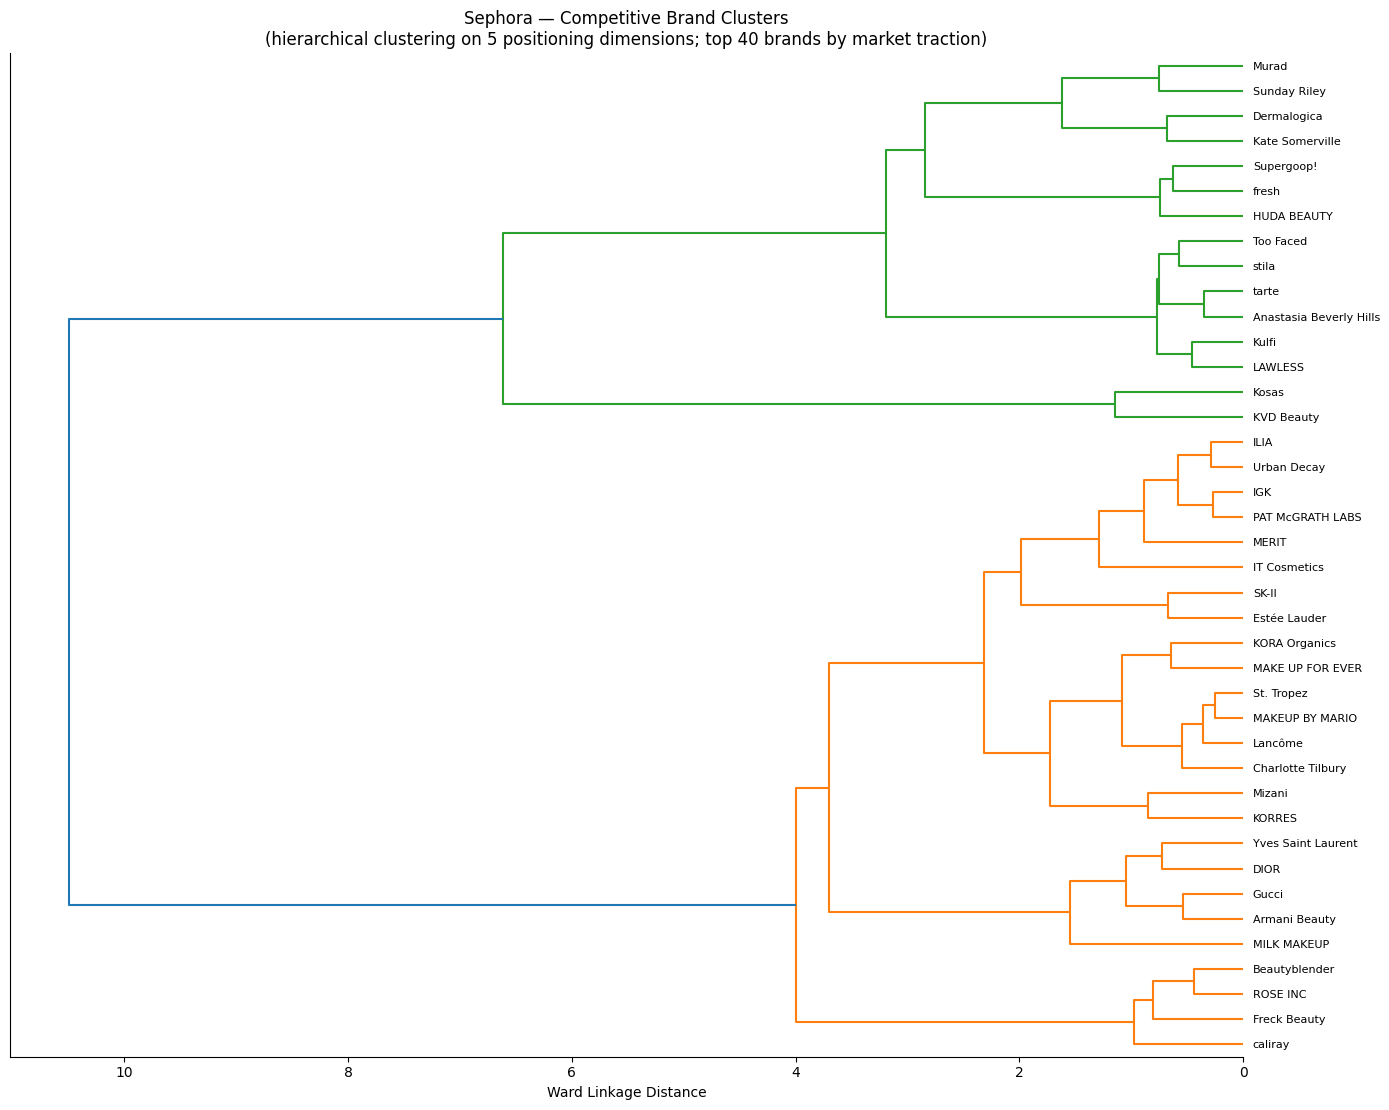

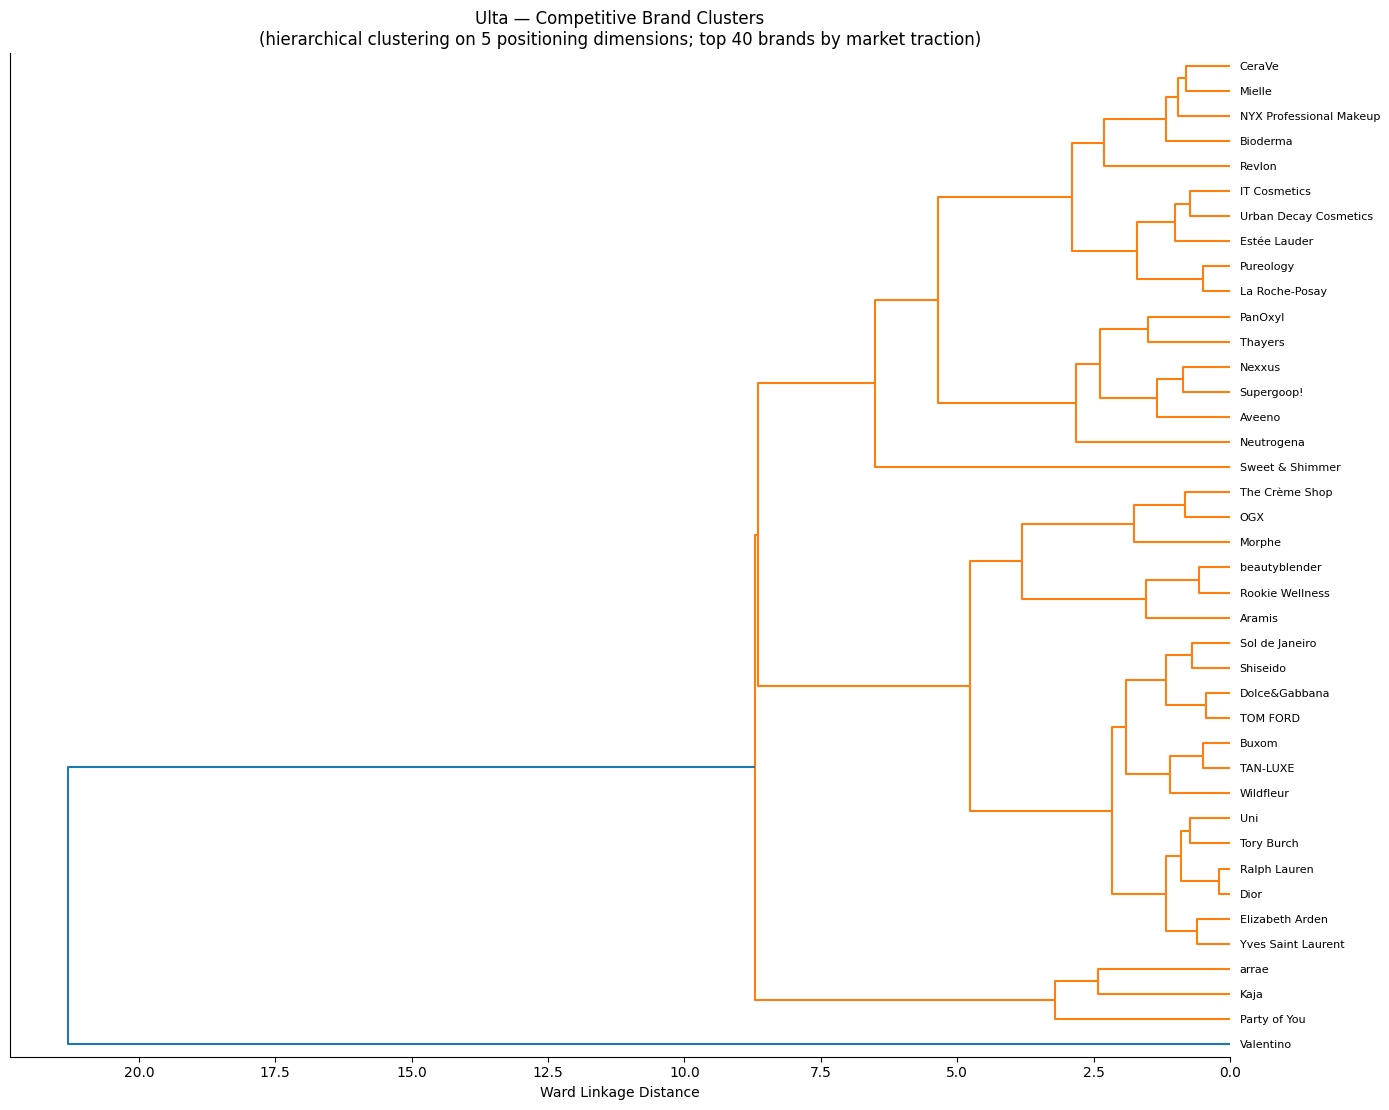

In [11]:
if len(shared_df) >= 6:
    for platform, color in [("Sephora", SEPHORA_COLOR), ("Ulta", ULTA_COLOR)]:
        sub = (pca_df[pca_df["platform"] == platform]
               .dropna(subset=SCORE_COLS)
               .set_index("brand"))
        sub_norm = (sub[SCORE_COLS] - sub[SCORE_COLS].mean()) / (sub[SCORE_COLS].std() + 1e-9)

        # Cap at top 40 brands by traction for readability
        if "market_traction" in sub.columns:
            sub_norm = sub_norm.loc[sub["market_traction"].nlargest(40).index]

        Z   = linkage(sub_norm.values, method="ward", metric="euclidean")
        fig, ax = plt.subplots(figsize=(14, max(6, len(sub_norm) * 0.28)))
        dendrogram(
            Z, labels=sub_norm.index.tolist(),
            orientation="left", ax=ax,
            color_threshold=0.7 * max(Z[:, 2]),
            leaf_font_size=8,
        )
        ax.set_xlabel("Ward Linkage Distance", fontsize=10)
        ax.set_title(
            f"{platform} — Competitive Brand Clusters\n"
            "(hierarchical clustering on 5 positioning dimensions; "
            "top 40 brands by market traction)",
            fontsize=12
        )
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"3.1_dendrogram_{platform.lower()}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

In [12]:
print("  3.1  COMPETITIVE POSITIONING — SUMMARY")

print(f"\nPositioning dimensions: {', '.join(SCORE_COLS)}")
print(f"Total brand-platform observations : {len(pca_df):,}")
print(f"Sephora brands analysed           : {(pca_df['platform']=='Sephora').sum():,}")
print(f"Ulta brands analysed              : {(pca_df['platform']=='Ulta').sum():,}")
print(f"Shared brands (cross-platform)    : {len(both_brands):,}")

print(f"\nPCA variance explained:")
for i, ev in enumerate(explained):
    print(f"  PC{i+1}: {ev:.1%}  (cumulative {explained[:i+1].sum():.1%})")

print(f"\nTop loading on PC1 (primary competitive axis):")
print(loadings["PC1"].sort_values(ascending=False).round(3).to_string())
print(f"\nTop loading on PC2 (secondary competitive axis):")
print(loadings["PC2"].sort_values(ascending=False).round(3).to_string())

for platform, df_brand in [("Sephora", s_scores), ("Ulta", u_scores)]:
    sub = df_brand.dropna(subset=SCORE_COLS)
    if len(sub) == 0:
        continue
    print(f"\n{platform} — top 5 brands by efficacy:")
    if "efficacy" in sub.columns:
        for _, row in sub.nlargest(5, "efficacy").iterrows():
            print(f"  {row['brand']:<35} efficacy={row['efficacy']:.4f}  "
                  f"n={row['n_products']}")
    print(f"{platform} — top 5 brands by market traction:")
    if "market_traction" in sub.columns:
        for _, row in sub.nlargest(5, "market_traction").iterrows():
            print(f"  {row['brand']:<35} traction={row['market_traction']:.4f}  "
                  f"n={row['n_products']}")

  3.1  COMPETITIVE POSITIONING — SUMMARY

Positioning dimensions: efficacy, experience_quality, polarization, market_traction, value_efficiency
Total brand-platform observations : 856
Sephora brands analysed           : 301
Ulta brands analysed              : 555
Shared brands (cross-platform)    : 100

PCA variance explained:
  PC1: 49.9%  (cumulative 49.9%)
  PC2: 24.4%  (cumulative 74.2%)
  PC3: 16.3%  (cumulative 90.6%)
  PC4: 5.9%  (cumulative 96.5%)

Top loading on PC1 (primary competitive axis):
polarization          0.571
value_efficiency      0.196
market_traction      -0.276
efficacy             -0.505
experience_quality   -0.552

Top loading on PC2 (secondary competitive axis):
market_traction       0.683
polarization         -0.061
experience_quality   -0.201
efficacy             -0.435
value_efficiency     -0.548

Sephora — top 5 brands by efficacy:
  Bounce Curl                         efficacy=2.3333  n=1
  Dezi Skin                           efficacy=2.3067  n=5
  Ebb O

The competitive landscape is two-dimensional in a meaningful way. PC1 and PC2 together explain 74% of variance, and the loadings tell a clean story. PC1 is essentially a quality-vs-polarization axis — high positive scores mean more polarizing and less loved, high negative scores mean high efficacy and positive sentiment. PC2 is a market visibility axis — high scores mean high review velocity and traction, low scores mean value-efficient but quieter. So a brand's position in perceptual space is fully described by roughly: how divisive are you × how loud are you.

The efficacy scores hitting 2.3 are a normalization artifact. Your composite averages avg_rating, pct_5_star, and pct_positive — all of which are on different scales before being mean-averaged. Bounce Curl and CROC aren't meaningfully "better" than Charlotte Tilbury, they just have small n products where every review happened to be 5-star. For the writeup you'd want to either standardize within each component before averaging, or filter to brands with ≥5 products for the top-brands table. The traction ranking is more trustworthy since it's a raw feature mean.

The traction rankings reveal a platform character difference. Sephora's most-reviewed brands (KORRES, KVD, stila) are legacy prestige or cult indie — brands with established communities. Ulta's top is Valentino at 253 reviews/month, which is almost certainly fragrance driven (Valentino Beauty launched aggressively at Ulta), followed by mass-accessible brands like Neutrogena. This is consistent with Ulta's dual prestige-mass positioning, but it means the PC2 axis (traction) captures somewhat different phenomena on each platform — prestige community engagement on Sephora vs. mass volume on Ulta.

100 shared brands out of 301 Sephora brands (33%) is the key cross-platform number. Two thirds of Sephora's brand roster isn't at Ulta at all, which means the perceptual map overlay is capturing the genuinely cross-channel brands — likely the higher-end ones. If you check where those 100 shared brands sit on the Sephora PC1 axis, they almost certainly skew toward the negative end (higher efficacy, lower polarization), confirming that Ulta's prestige shelf is a curated subset of Sephora's.

For the writeup, the clearest narrative is: PC1 separates beloved niche from polarizing mass, PC2 separates high-visibility from quiet value. The four quadrants that emerge — beloved-loud (premium leaders), beloved-quiet (loyal niche), polarizing-loud (controversial mainstream), polarizing-quiet (underperformers) — map almost perfectly onto your four Sephora cluster labels from section 2.2, which is a nice validation that the segmentation and the competitive positioning are telling the same story from different angles.